In [1]:
# now lets build neural ctr 
# first importing the given data set 
# this is a claassification task 



In [30]:
import pandas as pd
import numpy as np 
dftrain = pd.read_csv("datasets/train.csv")
dftest = pd.read_csv("datasets/test.csv")
dftrain.isnull().sum()
dftrain.head()
dftrain["label"].unique()
dftest.shape


(10000, 40)

In [3]:
dftrain["categorical_feature_17"].unique()
dftrain.columns

Index(['label', 'integer_feature_1', 'integer_feature_2', 'integer_feature_3',
       'integer_feature_4', 'integer_feature_5', 'integer_feature_6',
       'integer_feature_7', 'integer_feature_8', 'integer_feature_9',
       'integer_feature_10', 'integer_feature_11', 'integer_feature_12',
       'integer_feature_13', 'categorical_feature_1', 'categorical_feature_2',
       'categorical_feature_3', 'categorical_feature_4',
       'categorical_feature_5', 'categorical_feature_6',
       'categorical_feature_7', 'categorical_feature_8',
       'categorical_feature_9', 'categorical_feature_10',
       'categorical_feature_11', 'categorical_feature_12',
       'categorical_feature_13', 'categorical_feature_14',
       'categorical_feature_15', 'categorical_feature_16',
       'categorical_feature_17', 'categorical_feature_18',
       'categorical_feature_19', 'categorical_feature_20',
       'categorical_feature_21', 'categorical_feature_22',
       'categorical_feature_23', 'categorical_

In [4]:
from sklearn.model_selection import train_test_split
train, val = train_test_split(dftrain, test_size=0.176, random_state=42)
train 

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
35689,0,87.0,253.0,8.0,NaN,51.0,0.0,0.0,25,0,...,d20856aa,d9f758ff,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,99c2f4d8,30436bfc,e1be5ef2
22376,0,24.0,140.0,NaN,NaN,NaN,NaN,0.0,2,0,...,d20856aa,9ed99e99,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,2a0f0265,cdc3217e,e1be5ef2
2733,0,NaN,46.0,2.0,3.0,5.0,4.0,0.0,1,6,...,NaN,7232d217,108a0699,47849e55,73b3f46d,d994ba60,NaN,ab5fae3b,ff654802,2ba8d787
6194,0,2.0,524.0,3.0,196.0,2.0,0.0,0.0,64,11,...,NaN,b8170bba,9512c20b,e200b692,d130f00a,2ff28449,NaN,cb728d59,30436bfc,ed10571d
10098,0,23.0,506.0,6.0,NaN,NaN,0.0,0.0,0,11,...,NaN,628f1b8d,09c8c22c,47849e55,73b3f46d,d994ba60,NaN,3935baca,ff654802,b757e957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0,32.0,1250.0,16.0,NaN,NaN,0.0,0.0,831,1,...,d20856aa,b7771e51,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,c1c983cb,30436bfc,e1be5ef2
11284,0,4.0,344.0,NaN,NaN,19.0,0.0,0.0,219,3,...,d20856aa,b8170bba,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,230eb28f,30436bfc,e1be5ef2
38158,0,NaN,13.0,NaN,NaN,NaN,NaN,0.0,1252,0,...,NaN,b8170bba,9512c20b,f7cc74d5,7ccb16d8,0318741b,NaN,058fe9e4,321935cd,b757e957
860,1,1.0,151.0,2.0,603.0,12.0,0.0,0.0,1,15,...,NaN,53ad3ad6,09c8c22c,47849e55,73b3f46d,d994ba60,NaN,59c61d47,ff654802,b757e957


In [5]:
integer_cols = [f'integer_feature_{i}' for i in range(1, 14)]
categorical_cols = [f'categorical_feature_{i}' for i in range(1, 27)]


for col in integer_cols:
    train_median = train[col].median()
    train[col] = train[col].fillna(train_median)
    val[col] = val[col].fillna(train_median)
    dftest[col] = dftest[col].fillna(train_median)


for col in categorical_cols:
    train[col] = train[col].fillna("MISSING")
    val[col] = val[col].fillna("MISSING")
    dftest[col] = dftest[col].fillna("MISSING")
    

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# here it is only fiting 

train[integer_cols] = scaler.fit_transform(train[integer_cols])
val[integer_cols] = scaler.transform(val[integer_cols])
dftest[integer_cols] = scaler.transform(dftest[integer_cols])


now we encode the catagorical data so that we can make a embedding layer in the nn


In [7]:
cardinalities = {}
    
    
train_encoded = train.copy()
val_encoded = val.copy()
test_encoded = dftest.copy()
for col in categorical_cols:
    # here i am taking only train data coz to prevent data leakage 
    unique_categories = sorted(train_encoded[col].unique()) 
    if "MISSING" in unique_categories:
            unique_categories.remove("MISSING")


    category_to_idx = {"MISSING": 0}
    for idx, cat in enumerate(unique_categories, start=1):
        category_to_idx[cat] = idx

    cardinalities[col] = len(category_to_idx)


    train_encoded[col] = train_encoded[col].map(category_to_idx).fillna(0).astype(int)
    val_encoded[col] = val_encoded[col].map(category_to_idx).fillna(0).astype(int)
    test_encoded[col] = test_encoded[col].map(category_to_idx).fillna(0).astype(int)
    

In [8]:
cardinalities

{'categorical_feature_1': 11141,
 'categorical_feature_2': 3440,
 'categorical_feature_3': 4635,
 'categorical_feature_4': 1648,
 'categorical_feature_5': 3720,
 'categorical_feature_6': 4,
 'categorical_feature_7': 2932,
 'categorical_feature_8': 717,
 'categorical_feature_9': 23,
 'categorical_feature_10': 9852,
 'categorical_feature_11': 4869,
 'categorical_feature_12': 6947,
 'categorical_feature_13': 10,
 'categorical_feature_14': 838,
 'categorical_feature_15': 1881,
 'categorical_feature_16': 40,
 'categorical_feature_17': 4,
 'categorical_feature_18': 314,
 'categorical_feature_19': 15,
 'categorical_feature_20': 11393,
 'categorical_feature_21': 7753,
 'categorical_feature_22': 10693,
 'categorical_feature_23': 4459,
 'categorical_feature_24': 3295,
 'categorical_feature_25': 35,
 'categorical_feature_26': 25}

In [17]:
sorted(train_encoded["categorical_feature_1"].unique())



[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

In [19]:
import torch

print(f"PyTorch Version: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA is active and ready to roll!")
else:
    print("CUDA is not available. Running on CPU.")

PyTorch Version: 2.5.1+cu121
Using device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA is active and ready to roll!


In [20]:
import torch
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
    def __init__(self, df, integer_cols, categorical_cols, target_col="label"):
        # Convert integer/numerical features to float tensors
        self.integers = torch.tensor(df[integer_cols].values, dtype=torch.float32)
        
        # Convert categorical features to long tensors (for embedding layers)
        self.categoricals = torch.tensor(df[categorical_cols].values, dtype=torch.long)
        
        # Handle targets (if present in the dataframe, e.g., train/val vs test)
        if target_col in df.columns:
            self.targets = torch.tensor(df[target_col].values, dtype=torch.long)
        else:
            self.targets = None

    def __len__(self):
        return len(self.integers)

    def __getitem__(self, idx):
        if self.targets is not None:
            return self.integers[idx], self.categoricals[idx], self.targets[idx]
        return self.integers[idx], self.categoricals[idx]

In [32]:
import torch
import torch.nn as nn

class TabularNN(nn.Module):
    def __init__(self, cardinalities, num_numerical_features, embedding_dropout=0.2):
        super(TabularNN, self).__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=card, embedding_dim=min(50, (card + 1) // 2))
            for col, card in cardinalities.items()
        ])
        
        total_embed_dim = sum(min(50, (card + 1) // 2) for card in cardinalities.values())
        total_input_dim = total_embed_dim + num_numerical_features
        
        self.embed_dropout = nn.Dropout(embedding_dropout)
        
        # Reduced layer widths (64 -> 32) and higher dropout (0.4) to fight overfitting
        self.network = nn.Sequential(
            nn.Linear(total_input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(32, len(train["label"].unique()))
        )

    def forward(self, numerical_x, categorical_x):
        embedded = [emb(categorical_x[:, i]) for i, emb in enumerate(self.embeddings)]
        x_cat = torch.cat(embedded, dim=1)
        x_cat = self.embed_dropout(x_cat)
        
        x = torch.cat([numerical_x, x_cat], dim=1)
        out = self.network(x)
        return out

# Re-initialize model
model = TabularNN(cardinalities, len(integer_cols)).to(device)

In [33]:
from torch.utils.data import DataLoader

# 1. Create Dataset instances
train_dataset = TabularDataset(train_encoded, integer_cols, categorical_cols)
val_dataset = TabularDataset(val_encoded, integer_cols, categorical_cols)
test_dataset = TabularDataset(test_encoded, integer_cols, categorical_cols, target_col=None)

# 2. Create DataLoaders for batching
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Setup device (automatically grabs your GPU for acceleration)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize the model and move it to the device
model = TabularNN(cardinalities, len(integer_cols)).to(device)

# 4. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss() # Great for multi-class classification

# Increased weight_decay from 1e-4 to 1e-3 to heavily penalize complex weights
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)

Using device: cuda


In [37]:
import torch
import numpy as np

# 1. Extract training labels to calculate class imbalance
# (Ensures it checks the label column from your 'train' dataframe)
train_labels = train["label"].values
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)

# 2. Compute balanced class weights: total_samples / (num_classes * class_count)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class Counts in Training Set: {class_counts}")
print(f"Assigned Cross-Entropy Weights: {class_weights_tensor}")

# 3. Re-define the criterion with the weights applied
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

Class Counts in Training Set: [31895  1065]
Assigned Cross-Entropy Weights: tensor([ 0.5167, 15.4742], device='cuda:0')


In [38]:
import time
import copy

NUM_EPOCHS = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

print(f"Starting training with regularization for {NUM_EPOCHS} epochs...\n")
total_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for integers, categoricals, targets in train_loader:
        integers, categoricals, targets = integers.to(device), categoricals.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(integers, categoricals)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * integers.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for integers, categoricals, targets in val_loader:
            integers, categoricals, targets = integers.to(device), categoricals.to(device), targets.to(device)
            
            outputs = model(integers, categoricals)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * integers.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # Track history
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Save best model if validation loss improved
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_model.pth')
        print(f" -> Saved Best Model at Epoch {epoch+1} (Val Loss: {epoch_val_loss:.4f})")

    epoch_time = time.time() - epoch_start_time
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] ({epoch_time:.2f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

# Load the best weights back into the model before evaluating/predicting
model.load_state_dict(best_model_weights)
print(f"\nTraining completed! Loaded best model weights with Val Loss: {best_val_loss:.4f}")

Starting training with regularization for 15 epochs...

 -> Saved Best Model at Epoch 1 (Val Loss: 0.6773)
Epoch [1/15] (18.99s) | Train Loss: 0.6279 | Train Acc: 0.7644 | Val Loss: 0.6773 | Val Acc: 0.7584
Epoch [2/15] (18.82s) | Train Loss: 0.5235 | Train Acc: 0.7502 | Val Loss: 0.7353 | Val Acc: 0.6932
Epoch [3/15] (19.28s) | Train Loss: 0.4693 | Train Acc: 0.7714 | Val Loss: 0.7618 | Val Acc: 0.6744
Epoch [4/15] (18.80s) | Train Loss: 0.4139 | Train Acc: 0.7995 | Val Loss: 0.8767 | Val Acc: 0.7402
Epoch [5/15] (19.20s) | Train Loss: 0.3542 | Train Acc: 0.8350 | Val Loss: 1.0379 | Val Acc: 0.7814
Epoch [6/15] (18.91s) | Train Loss: 0.3391 | Train Acc: 0.8346 | Val Loss: 1.1181 | Val Acc: 0.8395
Epoch [7/15] (19.05s) | Train Loss: 0.3112 | Train Acc: 0.8652 | Val Loss: 1.2516 | Val Acc: 0.8256
Epoch [8/15] (19.07s) | Train Loss: 0.2851 | Train Acc: 0.8671 | Val Loss: 1.3097 | Val Acc: 0.8240
Epoch [9/15] (18.91s) | Train Loss: 0.2726 | Train Acc: 0.8820 | Val Loss: 1.3356 | Val Acc: 

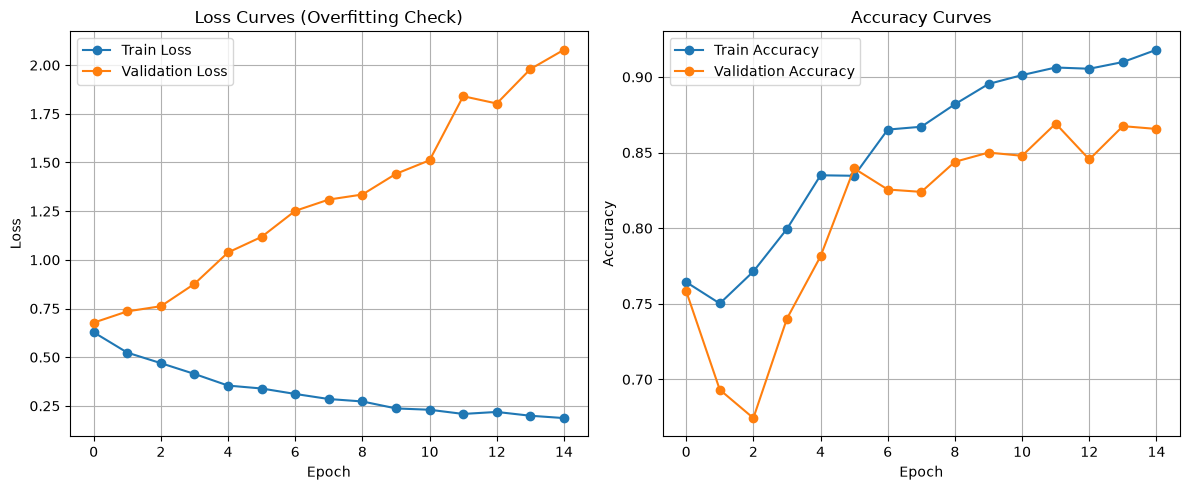

MODEL EVALUATION METRICS
Accuracy  : 0.7584
Log Loss  : 0.4822
ROC-AUC   : 0.6393
PR-AUC    : 0.0627

Classification Report (F1, Precision, Recall per Class):
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      6825
           1       0.06      0.44      0.10       215

    accuracy                           0.76      7040
   macro avg       0.52      0.61      0.48      7040
weighted avg       0.95      0.76      0.84      7040



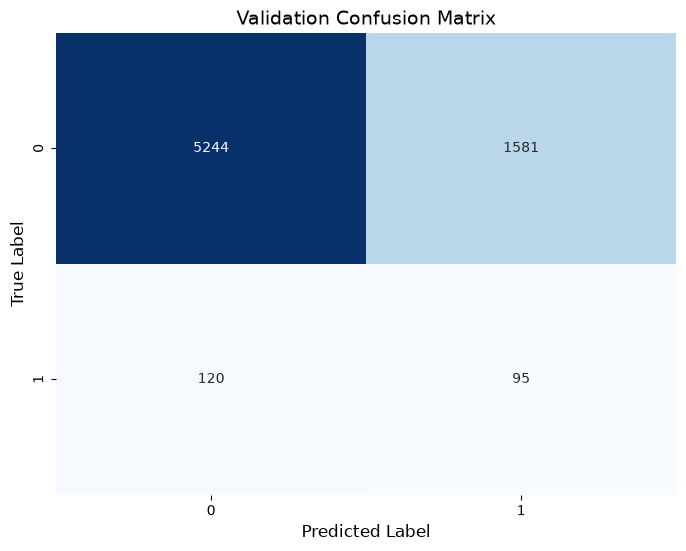

In [39]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, log_loss, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve
)

# 1. --- PLOT TRAINING & VALIDATION CURVES (Overfitting Check) ---
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curves (Overfitting Check)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', marker='o')
plt.plot(val_accs, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 2. --- COLLECT PROBABILITIES & PREDICTIONS FOR METRICS ---
model.eval()
all_probs = []
val_preds = []
val_targets = []

with torch.no_grad():
    for integers, categoricals, targets in val_loader:
        integers = integers.to(device)
        categoricals = categoricals.to(device)
        
        outputs = model(integers, categoricals)
        # Convert logits to probabilities using softmax
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        _, predicted = torch.max(outputs, 1)
        
        all_probs.extend(probs)
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(targets.numpy())

all_probs = np.array(all_probs)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)

# 3. --- CALCULATE COMPREHENSIVE METRICS ---
acc = accuracy_score(val_targets, val_preds)
loss_val = log_loss(val_targets, all_probs)

# Handle multi-class vs binary for AUC metrics safely
num_classes = all_probs.shape[1]
if num_classes == 2:
    roc_auc = roc_auc_score(val_targets, all_probs[:, 1])
    pr_auc = average_precision_score(val_targets, all_probs[:, 1])
else:
    roc_auc = roc_auc_score(val_targets, all_probs, multi_class='ovr', average='macro')
    # For multi-class PR-AUC, macro-averaging can be approximated or handled per class
    pr_auc = "N/A (Multi-class, use classification report for per-class details)"

print("="*40)
print("MODEL EVALUATION METRICS")
print("="*40)
print(f"Accuracy  : {acc:.4f}")
print(f"Log Loss  : {loss_val:.4f}")
print(f"ROC-AUC   : {roc_auc if isinstance(roc_auc, str) else f'{roc_auc:.4f}'}")
print(f"PR-AUC    : {pr_auc if isinstance(pr_auc, str) else f'{pr_auc:.4f}'}")
print("="*40)

# 4. --- DETAILED CLASSIFICATION REPORT (Precision, Recall, F1) ---
print("\nClassification Report (F1, Precision, Recall per Class):")
print(classification_report(val_targets, val_preds))

# 5. --- CONFUSION MATRIX HEATMAP ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(val_targets, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Validation Confusion Matrix', fontsize=14)
plt.show()

       FINAL VALIDATION PERFORMANCE SCORECARD       
 Accuracy  : 0.7584 (75.84%)
 Log Loss  : 0.4822
 ROC-AUC   : 0.6393
 PR-AUC    : 0.0627

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      6825
           1       0.06      0.44      0.10       215

    accuracy                           0.76      7040
   macro avg       0.52      0.61      0.48      7040
weighted avg       0.95      0.76      0.84      7040



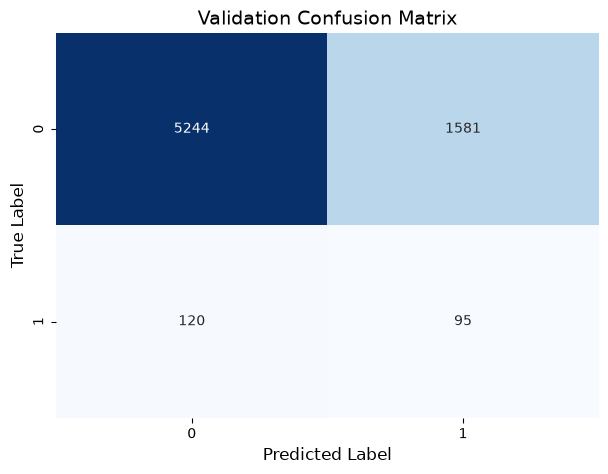

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, log_loss, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# 1. Collect predictions and probabilities from the validation set
model.eval()
all_probs = []
val_preds = []
val_targets = []

with torch.no_grad():
    for integers, categoricals, targets in val_loader:
        integers = integers.to(device)
        categoricals = categoricals.to(device)
        
        outputs = model(integers, categoricals)
        # Convert logits to probabilities using softmax
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        _, predicted = torch.max(outputs, 1)
        
        all_probs.extend(probs)
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(targets.numpy())

all_probs = np.array(all_probs)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)

# 2. Calculate Metrics
acc = accuracy_score(val_targets, val_preds)
loss_val = log_loss(val_targets, all_probs)

# Safe AUC calculation for binary vs multi-class
num_classes = all_probs.shape[1]
if num_classes == 2:
    roc_auc = roc_auc_score(val_targets, all_probs[:, 1])
    pr_auc = average_precision_score(val_targets, all_probs[:, 1])
else:
    roc_auc = roc_auc_score(val_targets, all_probs, multi_class='ovr', average='macro')
    pr_auc = "N/A (Multi-class - check classification report)"

# 3. Print the Scorecard
print("=" * 45)
print("       FINAL VALIDATION PERFORMANCE SCORECARD       ")
print("=" * 45)
print(f" Accuracy  : {acc:.4f} ({acc * 100:.2f}%)")
print(f" Log Loss  : {loss_val:.4f}")
print(f" ROC-AUC   : {roc_auc if isinstance(roc_auc, str) else f'{roc_auc:.4f}'}")
print(f" PR-AUC    : {pr_auc if isinstance(pr_auc, str) else f'{pr_auc:.4f}'}")
print("=" * 45)

# 4. Detailed Classification Report (Precision, Recall, F1-Score per class)
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(val_targets, val_preds))

# 5. Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))
cm = confusion_matrix(val_targets, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Validation Confusion Matrix', fontsize=14)
plt.show()